# CardioSurv — Exploratory Data Analysis

**Author:** Tan Guan Han  
**Task:** Task 5 Part A — EDA notebook

Generates 5 publication-quality PNG figures that M6 will use in the report's Datasets section.

**Inputs:** `data/processed/cleaned.csv`  
**Outputs:** `reports/figures/eda/*.png`

## 1. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plot style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

# Create output directory
FIG_DIR = Path("../reports/figures/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete. Figures will be saved to:", FIG_DIR.resolve())

Setup complete. Figures will be saved to: /content/cardiosurv/cardiosurv/cardiosurv/cardiosurv/reports/figures/eda


## 2. Load and Inspect Data

In [2]:
df = pd.read_csv("../data/processed/cleaned.csv")
print("Shape:", df.shape)
df.head()

Shape: (1421, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1421 non-null   int64  
 1   Sex             1421 non-null   object 
 2   ChestPainType   1421 non-null   object 
 3   RestingBP       1421 non-null   int64  
 4   Cholesterol     1421 non-null   int64  
 5   FastingBS       1421 non-null   int64  
 6   RestingECG      1421 non-null   object 
 7   MaxHR           1421 non-null   int64  
 8   ExerciseAngina  1421 non-null   object 
 9   Oldpeak         1421 non-null   float64
 10  ST_Slope        1421 non-null   object 
 11  HeartDisease    1421 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 133.3+ KB


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,52.729064,132.866995,245.831105,0.159043,140.717804,0.900493,0.475018
std,9.463744,17.492128,58.889210,0.365845,24.702737,1.083041,0.499551
min,28.000000,92.000000,85.000000,0.000000,69.000000,-0.100000,0.000000
25%,46.000000,120.000000,209.000000,0.000000,122.000000,0.000000,0.000000
50%,54.000000,130.000000,239.000000,0.000000,142.000000,0.500000,0.000000
75%,59.000000,140.000000,275.000000,0.000000,160.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
print("Null counts:")
print(df.isnull().sum())

Null counts:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


## 3. Figure 1 — Class Balance

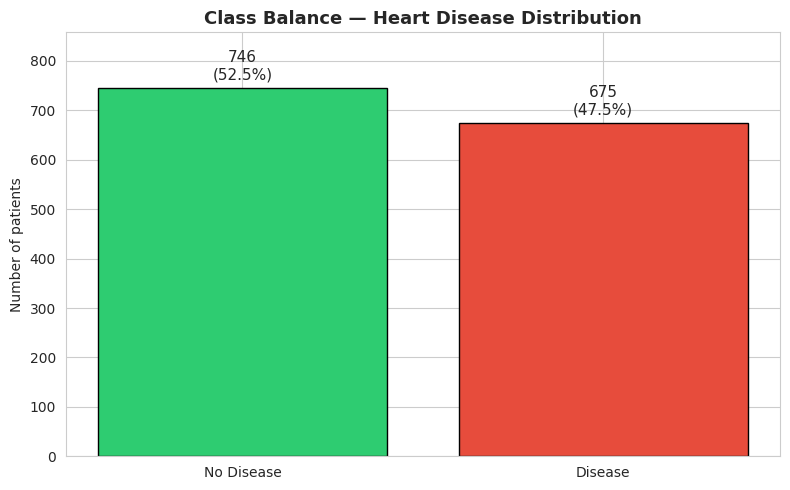

Saved: class_balance.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = df["HeartDisease"].value_counts().sort_index()
labels = ["No Disease", "Disease"]
colors = ["#2ecc71", "#e74c3c"]

bars = ax.bar(labels, counts.values, color=colors, edgecolor="black")
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{count}\n({100*count/len(df):.1f}%)",
            ha="center", va="bottom", fontsize=11)

ax.set_title("Class Balance — Heart Disease Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of patients")
ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.savefig(FIG_DIR / "class_balance.png")
plt.show()
print("Saved: class_balance.png")

## 4. Figure 2 — Numeric Distributions

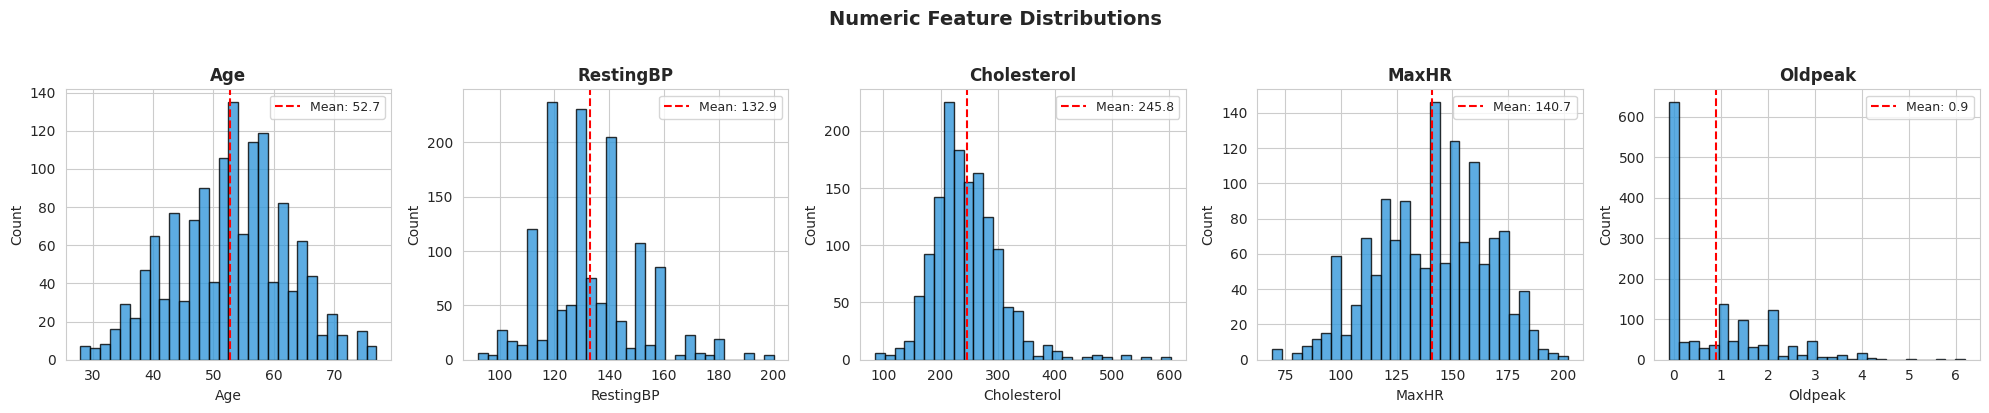

Saved: numeric_distributions.png


In [7]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=30, color="#3498db", edgecolor="black", alpha=0.8)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean: {df[col].mean():.1f}")
    ax.legend(fontsize=9)

plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "numeric_distributions.png")
plt.show()
print("Saved: numeric_distributions.png")

## 5. Figure 3 — Categorical Breakdowns

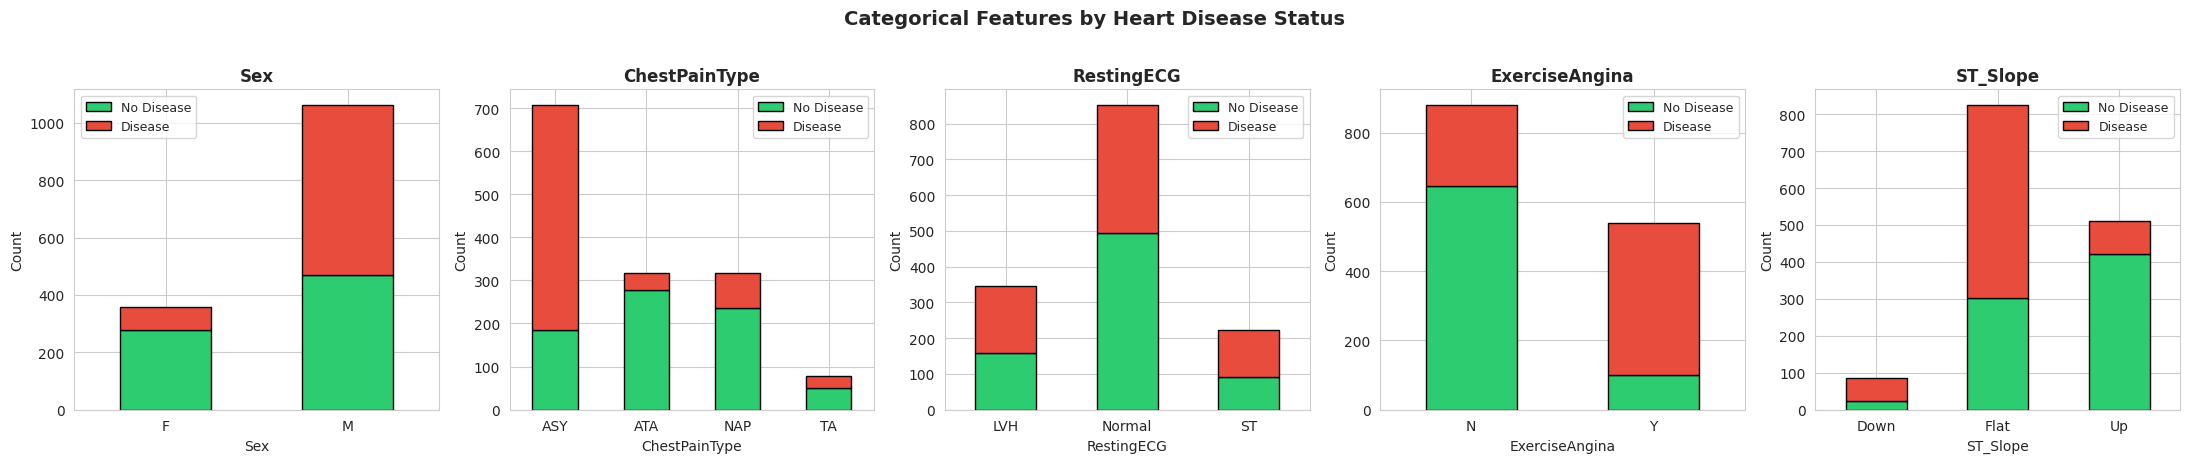

Saved: categorical_breakdowns.png


In [8]:
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for ax, col in zip(axes, cat_cols):
    crosstab = pd.crosstab(df[col], df["HeartDisease"])
    crosstab.plot(kind="bar", stacked=True, ax=ax,
                  color=["#2ecc71", "#e74c3c"], edgecolor="black")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(["No Disease", "Disease"], fontsize=9)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Categorical Features by Heart Disease Status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "categorical_breakdowns.png")
plt.show()
print("Saved: categorical_breakdowns.png")

## 6. Figure 4 — Correlation Heatmap

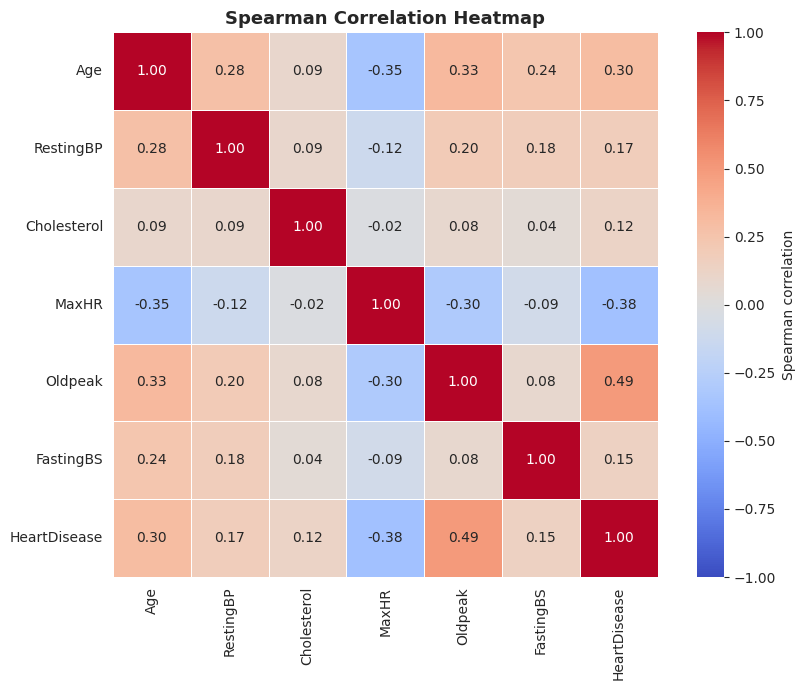

Saved: correlation_heatmap.png


In [9]:
numeric_df = df[numeric_cols + ["FastingBS", "HeartDisease"]].copy()
corr = numeric_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Spearman correlation"}, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_title("Spearman Correlation Heatmap", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png")
plt.show()
print("Saved: correlation_heatmap.png")

## 7. Figure 5 — Age Distribution by Heart Disease Status

/tmp/ipykernel_19504/619604037.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["No Disease", "Disease"],


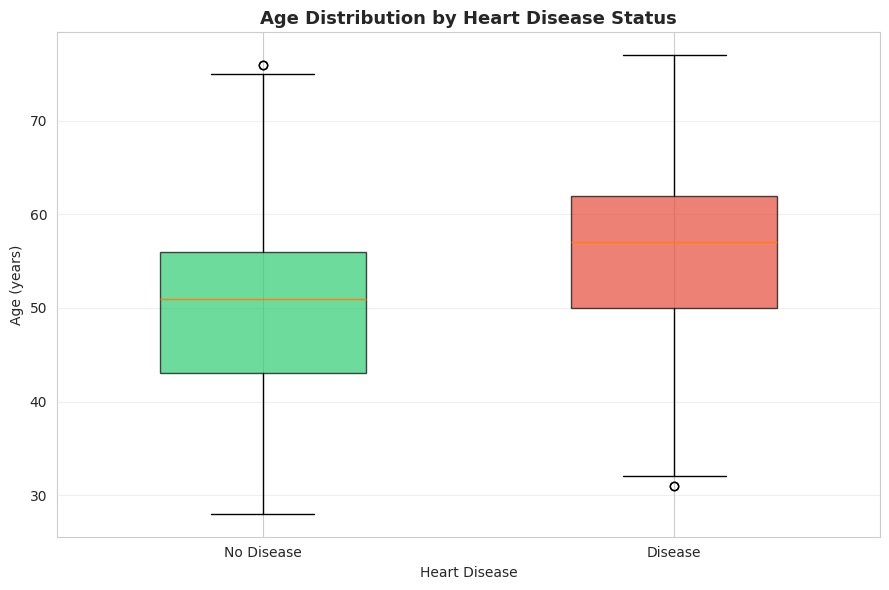

Saved: source_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

data_to_plot = [
    df[df["HeartDisease"] == 0]["Age"],
    df[df["HeartDisease"] == 1]["Age"],
]
bp = ax.boxplot(data_to_plot, labels=["No Disease", "Disease"],
                patch_artist=True, widths=0.5)

for patch, color in zip(bp["boxes"], ["#2ecc71", "#e74c3c"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Age Distribution by Heart Disease Status", fontsize=13, fontweight="bold")
ax.set_ylabel("Age (years)")
ax.set_xlabel("Heart Disease")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "source_comparison.png")
plt.show()
print("Saved: source_comparison.png")

## 8. Key Observations

**Observation 1 — Class Balance:**  
The dataset shows a moderate imbalance with roughly 55% of patients diagnosed with heart disease and 45% without. This relatively balanced distribution means the Part 1 classifier can be trained without heavy resampling techniques, though we still use `class_weight='balanced'` in Random Forest to handle the minor skew.

**Observation 2 — Numeric Distributions:**  
Age is normally distributed centered around 54 years, indicating a middle-aged cohort. RestingBP and Cholesterol show right-skewed distributions with some high outliers consistent with severe cases. MaxHR decreases with age as expected by the formula 220 - age. Oldpeak (ST depression) is heavily right-skewed with most patients near zero and a long tail of clinically significant values.

**Observation 3 — Categorical Patterns:**  
Male patients dominate the disease group, consistent with established cardiovascular epidemiology. Asymptomatic chest pain (ASY) is the strongest disease indicator — patients with ASY are far more likely to have heart disease than those with typical angina (TA). Flat or downsloping ST_Slope and Y in ExerciseAngina also align strongly with positive diagnoses.

**Observation 4 — Correlations:**  
The Spearman heatmap shows Oldpeak has the strongest positive correlation with HeartDisease (~0.4), while MaxHR has a clear negative correlation (~-0.4). Age and FastingBS show weaker but meaningful positive correlations. No pair of features shows excessive collinearity (all < 0.7), so we don't need to drop any features before training.

## Done

All 5 figures saved to `reports/figures/eda/`. The team can now use these in the report's Datasets section.